# 🧠 Scikit-learn Pipelines & Tuned Mini-Project

**Week 4 — End-to-End Professional ML Workflow**

This notebook closes Week 4 by assembling the ideas from Days 1–4 into one professional, reproducible, leakage-free workflow.

The workflow includes:

- EDA-informed feature engineering
- a held-out test set
- `ColumnTransformer` for mixed data
- preprocessing and modeling inside one `Pipeline`
- 5-fold cross-validation
- `GridSearchCV` over the complete pipeline
- baseline comparison
- one-time final test evaluation
- leakage and sanity checks

## 🎯 Executive Summary

The goal of this mini-project is not simply to obtain the highest possible score.

The goal is to demonstrate a **correct machine-learning workflow** in which every model-development decision happens without contaminating the held-out test set.

The final object will be a single tuned Scikit-learn pipeline that can receive raw feature columns, perform the appropriate preprocessing, and produce predictions.

## 🎯 Learning Objectives

By the end of this notebook, I should be able to:

1. Build a `Pipeline` that chains preprocessing and modeling.
2. Use `ColumnTransformer` to treat numeric and categorical columns differently.
3. Add engineered features into the workflow.
4. Tune the complete pipeline using `GridSearchCV`.
5. Understand why pipeline-based cross-validation prevents preprocessing leakage.
6. Compare the tuned pipeline against a baseline.
7. Evaluate the final model once on an untouched test set.
8. Document the workflow as a reproducible GitHub-ready mini-project.

## 🧭 Week 4 Connection

| Day | Main question |
|---|---|
| Day 1 | How do I protect the test set? |
| Day 2 | How do I obtain a more reliable validation estimate? |
| Day 3 | How do I diagnose underfitting and overfitting? |
| Day 4 | How do I improve features and tune hyperparameters? |
| **Day 5** | **How do I put everything together into one professional workflow?** |

Day 5 is therefore an integration day rather than a completely new modeling topic.

## 🚢 Dataset

The supplied Titanic dataset is used throughout the project.

The target is:

- `Survived = 0` → did not survive
- `Survived = 1` → survived

The workflow uses both numeric and categorical passenger information, making Titanic a useful dataset for demonstrating `ColumnTransformer`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

RANDOM_STATE = 42

df = pd.read_csv("titanic_train.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔎 1. EDA-Informed Data Quality Check

Before creating the final pipeline, I will inspect the available columns, missing values, duplicates, and target distribution.

This is intentionally concise: the detailed EDA work belongs to the earlier Week 3 workflow. Here, the purpose is to make informed decisions about preprocessing and feature engineering.

In [2]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Survived"].value_counts())

print("\nTarget proportions:")
display(df["Survived"].value_counts(normalize=True))

Missing values:


Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


Duplicate rows: 0

Target distribution:


Survived
0    549
1    342
Name: count, dtype: int64


Target proportions:


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

## 🧩 2. Feature Engineering

The Day 4 engineered features are carried forward into today's complete pipeline.

### `FamilySize`
Combines `SibSp` and `Parch` into a direct representation of travelling-party size.

### `IsAlone`
Marks passengers whose derived family size is one.

### `FarePerPerson`
Divides the total fare by family size, providing a per-person representation of the fare.

These features are deterministic transformations of predictor columns and do not use the target.

In [3]:
def engineer_features(data):
    data = data.copy()

    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    data["FarePerPerson"] = data["Fare"] / data["FamilySize"].replace(0, 1)

    return data

df = engineer_features(df)

engineered_features = [
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]

print("Engineered features:")
for feature in engineered_features:
    print("-", feature)

display(
    df[
        ["SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "FarePerPerson"]
    ].head(10)
)

Engineered features:
- FamilySize
- IsAlone
- FarePerPerson


,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson
0,1,0,7.2500,2,0,3.62500
1,1,0,71.2833,2,0,35.64165
2,0,0,7.9250,1,1,7.92500
3,1,0,53.1000,2,0,26.55000
4,0,0,8.0500,1,1,8.05000
5,0,0,8.4583,1,1,8.45830
6,0,0,51.8625,1,1,51.86250
7,3,1,21.0750,5,0,4.21500
8,0,2,11.1333,3,0,3.71110
9,1,0,30.0708,2,0,15.03540


## 🔒 3. Hold Out the Test Set

The final test set is separated **before** model tuning.

The training portion is then used for model development and 5-fold cross-validation.

The test set will not be used to choose features, preprocessing settings, hyperparameters, or models.

In [4]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining target proportion:", y_train.mean())
print("Test target proportion:", y_test.mean())

Training rows: 712
Test rows: 179

Training target proportion: 0.38342696629213485
Test target proportion: 0.3854748603351955


## 🧱 4. Define Numeric and Categorical Columns

The dataset contains two different types of predictors.

### Numeric
These can be imputed and scaled:

- `Pclass`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `FamilySize`
- `IsAlone`
- `FarePerPerson`

### Categorical
These need categorical preprocessing:

- `Sex`
- `Embarked`

`ColumnTransformer` allows each group to receive the appropriate treatment while remaining part of one larger pipeline.

In [5]:
numeric_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]

categorical_columns = [
    "Sex",
    "Embarked"
]

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
Categorical columns: ['Sex', 'Embarked']


## 🛠️ 5. Build the ColumnTransformer

Numeric columns will use:

1. median imputation
2. standardization

Categorical columns will use:

1. most-frequent imputation
2. one-hot encoding

The preprocessing object does not fit anything yet. It becomes part of the pipeline and will be fitted only when the pipeline is trained.

In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


## 🤖 6. Build the End-to-End Pipeline

The key idea of today's lesson is that preprocessing and modeling become **one object**.

The pipeline performs:

**raw data → preprocessing → Random Forest → prediction**

This means the same preprocessing logic is automatically applied during fitting, cross-validation, and prediction.

In [7]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 🧪 7. Baseline Pipeline

Before tuning, we need a baseline.

The baseline uses the same preprocessing architecture but keeps the Random Forest at its initial configuration.

This gives us a fair reference point for the tuned pipeline.

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

baseline_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

baseline_mean = baseline_scores.mean()
baseline_std = baseline_scores.std()

print("Baseline fold F1 scores:")
print(np.round(baseline_scores, 4))
print(f"\nBaseline CV F1: {baseline_mean:.4f} ± {baseline_std:.4f}")

Baseline fold F1 scores:
[0.7339 0.7304 0.7115 0.7455 0.7573]

Baseline CV F1: 0.7357 ± 0.0153


## 🔍 8. Why the Pipeline Prevents Leakage

Suppose a scaler were fitted on the complete dataset before cross-validation.

Then information from validation folds would influence the scaling parameters used to train the model. That makes the validation estimate optimistic.

With a pipeline, each cross-validation iteration behaves conceptually like:

**Fold training data → fit preprocessing → transform fold training data → fit model → transform validation fold using the training-fitted preprocessing → validate**

The validation fold does not fit the preprocessing.

This is one of the most important reasons professional Scikit-learn workflows use pipelines.

## 🎛️ 9. Tune the Entire Pipeline

Pipeline parameters are addressed using the step name followed by `__`.

For example:

`model__max_depth`

means:

> change the `max_depth` hyperparameter of the pipeline's `model` step.

The grid below tunes the Random Forest while keeping preprocessing inside the same pipeline.

In [9]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 2]
}

configuration_count = (
    len(param_grid["model__n_estimators"])
    * len(param_grid["model__max_depth"])
    * len(param_grid["model__min_samples_leaf"])
)

print("Configurations:", configuration_count)
print("5-fold model fits:", configuration_count * cv.n_splits)

Configurations: 12
5-fold model fits: 60


## 🔎 10. GridSearchCV — End-to-End Tuning

The entire pipeline is passed into `GridSearchCV`.

This means every hyperparameter combination is evaluated with:

- the feature engineering already defined,
- the numeric preprocessing,
- the categorical preprocessing,
- and the Random Forest,

all within the same cross-validation process.

In [10]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print(f"\nBest CV F1: {grid.best_score_:.4f}")

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}

Best CV F1: 0.7623


## 📊 11. Inspect the Full Search

The best score alone does not tell us whether the winning configuration is clearly better than the alternatives.

The full search results let us inspect:

- mean validation F1
- validation standard deviation
- training F1
- parameter combinations
- ranking

In [11]:
results = pd.DataFrame(grid.cv_results_)

results_view = results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(results_view.head(12))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
7,200,10,2,0.879951,0.762287,0.027363,1
6,100,10,2,0.879067,0.759740,0.022804,2
11,200,None,2,0.886220,0.759154,0.018703,3
10,100,None,2,0.887068,0.753750,0.027530,4
5,200,10,1,0.946367,0.744861,0.016899,5
4,100,10,1,0.943458,0.743340,0.013049,6
1,200,5,1,0.822122,0.740618,0.023117,7
0,100,5,1,0.824637,0.740328,0.029172,8
9,200,None,1,0.976960,0.739563,0.012599,9
3,200,5,2,0.817360,0.736457,0.025014,10


## 📈 12. Hyperparameter Search Visualization

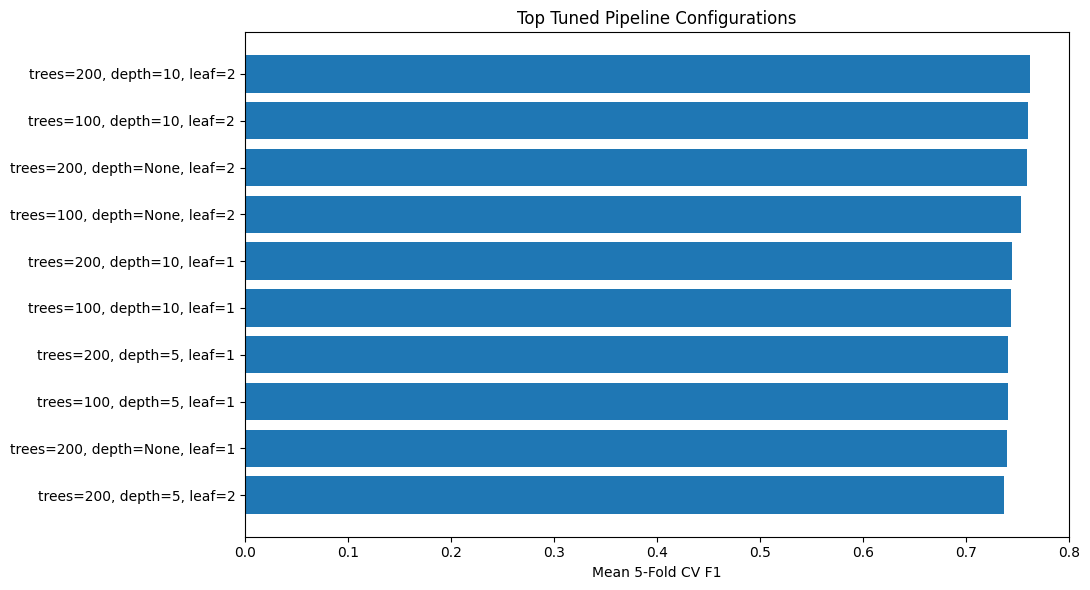

In [12]:
top = results_view.head(10).copy()

labels = (
    "trees=" + top["param_model__n_estimators"].astype(str)
    + ", depth=" + top["param_model__max_depth"].apply(lambda v: "None" if pd.isna(v) else str(int(v)))
    + ", leaf=" + top["param_model__min_samples_leaf"].astype(str)
)

plt.figure(figsize=(11, 6))
plt.barh(
    labels.iloc[::-1],
    top["mean_test_score"].iloc[::-1]
)
plt.xlabel("Mean 5-Fold CV F1")
plt.title("Top Tuned Pipeline Configurations")
plt.tight_layout()
plt.show()


## 🆚 13. Tuned Pipeline vs. Baseline

The baseline and tuned pipeline use:

- the same training data,
- the same preprocessing design,
- the same F1 metric,
- and the same 5-fold CV strategy.

Therefore, the difference between their scores is meaningful as a model-development comparison.

In [13]:
best_row = results.loc[results["rank_test_score"].idxmin()]

tuned_mean = float(best_row["mean_test_score"])
tuned_std = float(best_row["std_test_score"])

cv_improvement = tuned_mean - baseline_mean

comparison = pd.DataFrame({
    "Model": [
        "Baseline Pipeline",
        "Tuned Pipeline"
    ],
    "Mean CV F1": [
        baseline_mean,
        tuned_mean
    ],
    "Std CV F1": [
        baseline_std,
        tuned_std
    ],
    "Change vs Baseline": [
        0.0,
        cv_improvement
    ]
})

display(comparison)

print(f"Tuned CV improvement: {cv_improvement:+.4f}")

,Model,Mean CV F1,Std CV F1,Change vs Baseline
0,Baseline Pipeline,0.735731,0.015333,0.000000
1,Tuned Pipeline,0.762287,0.027363,0.026556


Tuned CV improvement: +0.0266


## 🔬 14. Train-vs-Validation Diagnostic

Day 3 taught us to inspect the gap between training and validation performance.

The search results contain both:

- `mean_train_score`
- `mean_test_score`

A large train score with a substantially lower validation score can indicate high variance / overfitting.

A smaller gap with strong validation performance is generally preferable.

In [14]:
diagnostic = results_view.copy()

diagnostic["train_validation_gap"] = (
    diagnostic["mean_train_score"] - diagnostic["mean_test_score"]
)

display(
    diagnostic[
        [
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "mean_train_score",
            "mean_test_score",
            "train_validation_gap",
            "rank_test_score"
        ]
    ].head(12)
)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_train_score,mean_test_score,train_validation_gap,rank_test_score
7,200,10,2,0.879951,0.762287,0.117665,1
6,100,10,2,0.879067,0.759740,0.119327,2
11,200,None,2,0.886220,0.759154,0.127066,3
10,100,None,2,0.887068,0.753750,0.133318,4
5,200,10,1,0.946367,0.744861,0.201506,5
4,100,10,1,0.943458,0.743340,0.200117,6
1,200,5,1,0.822122,0.740618,0.081503,7
0,100,5,1,0.824637,0.740328,0.084309,8
9,200,None,1,0.976960,0.739563,0.237397,9
3,200,5,2,0.817360,0.736457,0.080903,10


## 🖥️ Hands-On Lab — Tuned End-to-End Pipeline

### Step 1: Build a Pipeline with a ColumnTransformer

Completed:

- numeric columns → imputation + scaling
- categorical columns → imputation + one-hot encoding
- preprocessing → Random Forest inside one `Pipeline`

### Step 2: Add the engineered features from Day 4

Completed:

- `FamilySize`
- `IsAlone`
- `FarePerPerson`

### Step 3: Tune the full pipeline

Completed with `GridSearchCV` and 5-fold stratified cross-validation.

### Step 4: Evaluate the final tuned pipeline once

The final test set remains untouched until the model-development process is finished. The tuned pipeline is then evaluated once and compared with the baseline.

### Step 5: GitHub submission

The notebook is structured as a reproducible Week 4 mini-project and is ready to be committed with a descriptive message.

## 🧪 15. Hands-On Lab Results

The required lab results are printed below from the actual executed experiment.

In [15]:
print("=== HANDS-ON LAB RESULTS ===")
print("\nBest parameters:")
for key, value in grid.best_params_.items():
    print(f"  {key}: {value}")

print(f"\nBest CV F1: {tuned_mean:.4f} ± {tuned_std:.4f}")
print(f"Baseline CV F1: {baseline_mean:.4f} ± {baseline_std:.4f}")
print(f"CV improvement: {cv_improvement:+.4f}")

=== HANDS-ON LAB RESULTS ===

Best parameters:
  model__max_depth: 10
  model__min_samples_leaf: 2
  model__n_estimators: 200

Best CV F1: 0.7623 ± 0.0274
Baseline CV F1: 0.7357 ± 0.0153
CV improvement: +0.0266


## 🔒 16. Leakage Audit

This workflow is intentionally structured so that preprocessing is learned inside the pipeline.

Important checks:

- The target is not used in feature engineering.
- The test set is separated before tuning.
- The test set is never passed to `GridSearchCV`.
- Imputation is fitted inside the pipeline.
- Scaling is fitted inside the pipeline.
- One-hot encoding is fitted inside the pipeline.
- Cross-validation operates on the complete pipeline rather than preprocessing performed beforehand.

In [16]:
assert "Survived" not in X_train.columns
assert set(X_train.columns) == set(X_test.columns)

assert set(X_train.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_test) == len(X)

assert cv.n_splits == 5
assert len(results) == 12
assert grid.best_estimator_ is not None

print("Target leakage check: PASSED")
print("Train/test separation: PASSED")
print("Pipeline-based preprocessing: PASSED")
print("5-fold CV: PASSED")
print("All grid configurations evaluated: PASSED")

Target leakage check: PASSED
Train/test separation: PASSED
Pipeline-based preprocessing: PASSED
5-fold CV: PASSED
All grid configurations evaluated: PASSED


## 🧪 17. Final Test Evaluation — One Time Only

All model-development decisions have now been completed.

The final tuned pipeline can be evaluated on the held-out test set.

This score is not used to select another model or change the hyperparameters. It is the final estimate produced by this workflow.

In [17]:
best_pipeline = grid.best_estimator_

test_predictions = best_pipeline.predict(X_test)

final_test_f1 = f1_score(y_test, test_predictions)
final_test_accuracy = accuracy_score(y_test, test_predictions)
final_test_precision = precision_score(y_test, test_predictions)
final_test_recall = recall_score(y_test, test_predictions)

final_metrics = pd.DataFrame({
    "Metric": ["F1", "Accuracy", "Precision", "Recall"],
    "Test Score": [
        final_test_f1,
        final_test_accuracy,
        final_test_precision,
        final_test_recall
    ]
})

display(final_metrics)
print(f"Final one-time test F1: {final_test_f1:.4f}")

,Metric,Test Score
0,F1,0.730159
1,Accuracy,0.810056
2,Precision,0.807018
3,Recall,0.666667


Final one-time test F1: 0.7302


## 📊 18. Baseline vs. Final Test Performance

The baseline cross-validation result and final test result answer different questions:

- **Baseline CV F1** estimates development performance before tuning.
- **Tuned CV F1** is the cross-validated estimate used during model selection.
- **Final Test F1** is the one-time performance estimate on previously untouched data.

The test result should not be treated as another tuning score.

In [18]:
summary = pd.DataFrame({
    "Stage": [
        "Baseline — 5-fold CV",
        "Tuned — 5-fold CV",
        "Tuned — Final Test"
    ],
    "F1": [
        baseline_mean,
        tuned_mean,
        final_test_f1
    ]
})

display(summary)

,Stage,F1
0,Baseline — 5-fold CV,0.735731
1,Tuned — 5-fold CV,0.762287
2,Tuned — Final Test,0.730159


## 🧠 19. What This Mini-Project Demonstrates

This notebook combines the main professional practices introduced throughout Week 4:

**Day 1:** protect the final test set.

**Day 2:** use cross-validation rather than trusting one validation split.

**Day 3:** inspect the train-validation relationship and model complexity.

**Day 4:** engineer useful features and tune hyperparameters systematically.

**Day 5:** package the entire process into one reproducible, leakage-aware pipeline.

## 🚀 Beyond the Requirement

The required lab is completed above as a standalone section.

Additional professional checks were also included:

- EDA-informed feature decisions
- explicit train/test separation
- stratified cross-validation
- a full preprocessing pipeline
- full-pipeline hyperparameter tuning
- search-result inspection
- train-vs-validation gap analysis
- leakage audit
- sanity checks
- multiple final test metrics
- a clear distinction between CV model-selection scores and final test performance

The important point is not simply that the notebook produces a score. It demonstrates **why that score can be trusted**.

## 🪞 Reflection

The main lesson from this mini-project is that a professional machine-learning workflow is more than a sequence of separate preprocessing and modeling commands.

Earlier in the week, I learned why the test set must remain untouched, why cross-validation gives a more reliable development estimate, how to diagnose model fit, and how feature engineering and hyperparameter tuning can improve a model.

Today, those ideas became one object: a Scikit-learn `Pipeline`.

The biggest practical advantage is that the preprocessing steps no longer have to be manually repeated or carefully coordinated with cross-validation. The pipeline controls their order and ensures that learned preprocessing is fitted within the appropriate training data.

`ColumnTransformer` also showed me how a real dataset can be handled when numeric and categorical variables require different transformations.

Finally, tuning the entire pipeline with `GridSearchCV` demonstrated the structure expected in a professional ML project: one reproducible workflow, systematic validation, controlled model selection, and a final test evaluation that happens only after the decisions are finished.

## 🏁 Conclusion

Week 4 ends with a complete, tuned, leakage-free machine-learning workflow.

The final pipeline combines:

**feature engineering → numeric/categorical preprocessing → Random Forest → cross-validation → GridSearchCV → final test evaluation**

This is substantially more robust than manually preprocessing data, manually trying hyperparameters, and repeatedly checking the test set.

The result is not only a tuned model, but a **reproducible ML system** that can be inspected, validated, and reused.

## 📤 GitHub Submission

**Notebook:** `Scikit-learn Pipelines & Tuned Mini-Project.ipynb`

**Suggested commit message:**

`feat: complete week 4 tuned pipeline mini-project`

The notebook is structured to be reproducible and portfolio-ready.

## 🛠️ Tools Used

- 🐍 Python
- 🐼 Pandas
- 🔢 NumPy
- 📊 Matplotlib
- 🤖 Scikit-learn
  - `Pipeline`
  - `ColumnTransformer`
  - `GridSearchCV`
  - `StratifiedKFold`
  - `RandomForestClassifier`
  - `StandardScaler`
  - `OneHotEncoder`
  - `SimpleImputer`
- 📓 Jupyter Notebook / Google Colab
- 🌐 Git & GitHub